Liver Patient Dataset + SVM Classification

ရည်ရွယ်ချက်

လူနာတစ်ယောက်ရဲ့ သွေးစမ်းသပ်ချက်အချက်အလက်များကို အသုံးပြုပြီး
အသည်းရောဂါရှိ / မရှိ ကို Machine Learning နဲ့ ခွဲခြားသတ်မှတ်ခြင်း

In [36]:
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

%matplotlib inline

(1) Dataset ကို ဖတ်ယူခြင်း (Load CSV)

In [33]:
# 1. Load Dataset
DATA_PATH = r"C:\Users\thiny\OneDrive\Desktop\gittest\AI_2026\Day07 SVM\groupB\tyh_Liver_Patient\indian_liver_patient.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (583, 11)
   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65  Female              0.7               0.1                   187   
1   62    Male             10.9               5.5                   699   
2   62    Male              7.3               4.1                   490   
3   58    Male              1.0               0.4                   182   
4   72    Male              3.9               2.0                   195   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                          59             7.3   

   Albumin  Albumin_and_Globulin_Ratio  Dataset  
0      3.3             

In [37]:
# 2. Clean Column Names
# =========================
df.columns = df.columns.str.strip().str.replace(' ', '_')
print("\nColumns:", df.columns.tolist())


Columns: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']


In [38]:
# 3. Target Column
# =========================
if 'Dataset' in df.columns:
    df['Dataset'] = df['Dataset'].map({1:1, 2:0})
    target_col = 'Dataset'
elif 'class' in df.columns:
    target_col = 'class'
else:
    target_col = df.columns[-1]

print("Target column:", target_col)


Target column: Dataset


In [67]:
# 4. Select 2 Features (for Visualization)
# =========================
feature_cols = ['Total_Bilirubin', 'Total_Protiens']

df = df.dropna(subset=feature_cols + [target_col])

X = df[feature_cols]
y = df[target_col]

print("\nUsing features:", feature_cols)


Using features: ['Total_Bilirubin', 'Total_Protiens']


In [68]:
# 5. Train / Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [69]:
# 6. Scaling (IMPORTANT for SVM)
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [76]:
# 7. Train Linear SVM
# =========================
svm = SVC(kernel='linear', C=1000, random_state=42)
svm.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [77]:
# 8. Evaluation
# =========================
y_pred = svm.predict(X_test_scaled)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7094017094017094

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        34
           1       0.71      1.00      0.83        83

    accuracy                           0.71       117
   macro avg       0.35      0.50      0.41       117
weighted avg       0.50      0.71      0.59       117



c:\Users\thiny\anaconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thiny\anaconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thiny\anaconda3\envs\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

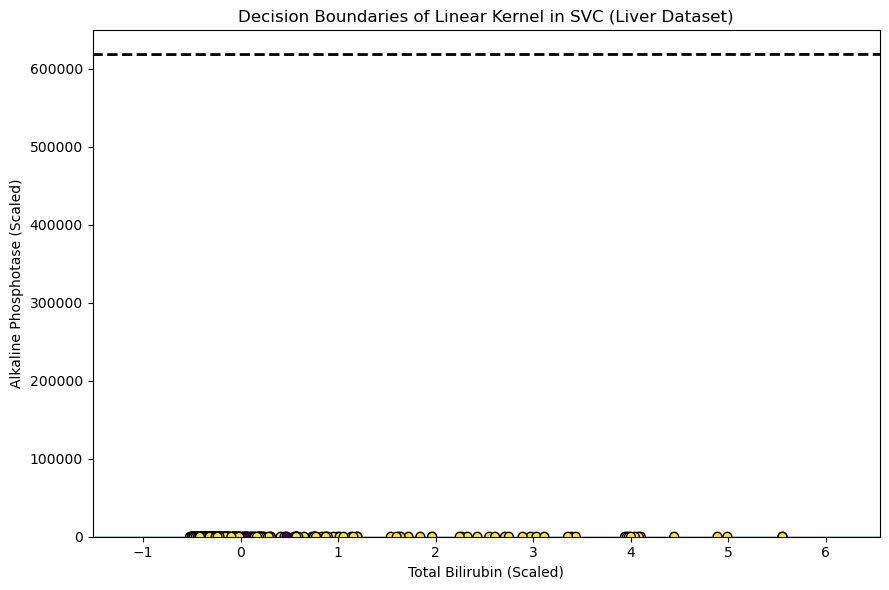

In [75]:

# 9. Decision Boundary Plot (FIXED)
# =========================
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, edgecolors="k", s=40)

# Decision Boundary Line
w = svm.coef_[0]
b = svm.intercept_[0]
x_line = np.linspace(x_min, x_max, 200)
y_line = -(w[0] * x_line + b) / w[1]
plt.plot(x_line, y_line, 'k--', linewidth=2)

plt.xlabel("Total Bilirubin (Scaled)")
plt.ylabel("Alkaline Phosphotase (Scaled)")
plt.title("Decision Boundaries of Linear Kernel in SVC (Liver Dataset)")
plt.tight_layout()
plt.show()